In [1]:
# Cell 1: Setup and Imports
"""
Customer Segmentation Using Clustering with Optuna Optimization

This notebook demonstrates hyperparameter optimization for clustering algorithms
using Optuna framework on the Online Retail dataset.
"""

import sys
sys.path.insert(0, '/workspace')

from Optuna_utils import *
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

print("Environment ready")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Optuna version: {optuna.__version__}")


Environment ready
Pandas version: 2.3.3
NumPy version: 2.2.6
Optuna version: 4.5.0


/usr/local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Cell 2: Load Data
"""
Load Online Retail dataset containing transaction records.
"""

df = load_data('online_retail.xlsx')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nData types:")
print(df.dtypes)
print(f"\nMissing values:")
print(df.isnull().sum())


Dataset shape: (541909, 8)

Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

First few rows:
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  

Data types:
InvoiceNo      

In [3]:
# Cell 3: Data Cleaning
"""
Clean transaction data:
- Remove duplicates
- Filter service codes (non-product transactions)
- Remove invalid prices
- Cap outliers
- Filter to valid transactions only
"""

df_clean = clean_data(df)

print(f"\nCleaning Results:")
print(f"Original rows: {df.shape[0]:,}")
print(f"Cleaned rows: {df_clean.shape[0]:,}")
print(f"Removed: {df.shape[0] - df_clean.shape[0]:,} ({100*(df.shape[0]-df_clean.shape[0])/df.shape[0]:.1f}%)")
print(f"\nUnique customers: {df_clean['CustomerID'].nunique():,}")
print(f"Date range: {df_clean['InvoiceDate'].min()} to {df_clean['InvoiceDate'].max()}")
print(f"Total revenue: ${df_clean['Revenue'].sum():,.2f}")



Cleaning Results:
Original rows: 541,909
Cleaned rows: 388,561
Removed: 153,348 (28.3%)

Unique customers: 4,333
Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00
Total revenue: $7,433,388.48


In [4]:
# Cell 4: Compute RFM Features
"""
RFM Analysis:
- Recency: Days since last purchase (lower = more recent)
- Frequency: Number of unique orders (higher = more loyal)
- Monetary: Total revenue contributed (higher = more valuable)

These 3 features capture customer value and engagement patterns.
"""

rfm = compute_rfm(df_clean)

print(f"RFM Features: {rfm.shape[0]:,} customers × {rfm.shape[1]} features")
print(f"\nRFM Statistics:")
print(rfm[['Recency', 'Frequency', 'Monetary']].describe())

print(f"\nDistribution checks:")
print(f"Recency range: {rfm['Recency'].min():.0f} - {rfm['Recency'].max():.0f} days")
print(f"Frequency range: {rfm['Frequency'].min():.0f} - {rfm['Frequency'].max():.0f} orders")
print(f"Monetary range: ${rfm['Monetary'].min():.2f} - ${rfm['Monetary'].max():.2f}")

RFM Features: 4,333 customers × 4 features

RFM Statistics:
           Recency    Frequency       Monetary
count  4333.000000  4333.000000    4333.000000
mean     92.723979     4.244403    1715.529305
std     100.179128     7.633759    5962.429132
min       1.000000     1.000000       3.750000
25%      18.000000     1.000000     290.400000
50%      51.000000     2.000000     641.920000
75%     143.000000     5.000000    1565.990000
max     374.000000   206.000000  209908.860000

Distribution checks:
Recency range: 1 - 374 days
Frequency range: 1 - 206 orders
Monetary range: $3.75 - $209908.86


In [5]:
# Cell 5: Feature Scaling
"""
Standardize RFM features using StandardScaler (z-score normalization).

Why StandardScaler:
- RFM features have different scales (days vs orders vs dollars)
- Clustering algorithms (especially K-Means, Hierarchical) are distance-based
- Without scaling, Monetary would dominate due to larger magnitude
- StandardScaler: mean=0, std=1 for each feature

Ensures equal weight for all three RFM dimensions.
"""

scaler = StandardScaler()
X = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

print(f"Scaled feature matrix: {X.shape}")
print(f"\nScaling verification:")
print(f"Mean per feature: {X.mean(axis=0)}")
print(f"Std per feature: {X.std(axis=0)}")
print(f"\nFirst 5 customers (scaled):")
print(X[:5])


Scaled feature matrix: (4333, 3)

Scaling verification:
Mean per feature: [ 8.93712880e-17 -3.27968029e-18  0.00000000e+00]
Std per feature: [1. 1. 1.]

First 5 customers (scaled):
[[ 2.3288578  -0.42505636 -0.27031186]
 [-0.90572209  0.36101671  0.4044994 ]
 [-0.17694329 -0.03201982 -0.06935043]
 [-0.73600648 -0.42505636 -0.04718409]
 [ 2.16912546 -0.42505636 -0.23837488]]


In [6]:
# Cell 5.5: Handle Extreme Outliers
"""
Problem: Extreme outliers ($200K customers) cause degenerate clusters.
Solution: Remove top outliers using z-score threshold.

Z-score > 3 indicates extreme outliers (beyond 99.7th percentile).
"""

from scipy.stats import zscore

# Calculate z-scores
z_scores = np.abs(zscore(X, axis=0))
outlier_mask = (z_scores > 3).any(axis=1)
n_outliers = outlier_mask.sum()

print(f"Extreme outliers detected: {n_outliers} ({100*n_outliers/len(X):.2f}%)")
print(f"\nOutlier customers (z-score > 3):")
print(rfm[outlier_mask][['Recency', 'Frequency', 'Monetary']].describe())

# Create clean dataset
X_clean = X[~outlier_mask]
rfm_clean = rfm[~outlier_mask].reset_index(drop=True)

print(f"\nCleaned dataset: {X_clean.shape[0]:,} customers (removed {n_outliers})")
print(f"Ready for optimization.")


Extreme outliers detected: 60 (1.38%)

Outlier customers (z-score > 3):
          Recency   Frequency       Monetary
count   60.000000   60.000000      60.000000
mean    12.633333   46.633333   32721.239000
std     47.775948   36.330856   37060.816405
min      1.000000    6.000000    1173.980000
25%      1.750000   29.750000    9974.155000
50%      4.000000   35.000000   19878.990000
75%      9.000000   50.250000   39804.067500
max    372.000000  206.000000  209908.860000

Cleaned dataset: 4,273 customers (removed 60)
Ready for optimization.


In [7]:
# Cell 6: Optimize K-Means with Optuna
"""
K-Means Optimization:

Hyperparameters:
- n_clusters: [3, 8] - business typically needs 3-8 segments
- init: ['k-means++', 'random'] - initialization strategy
- n_init: [10, 30] - number of random restarts for stability

Objective: Multi-objective composite score
- 50% Silhouette (cluster separation)
- 30% Davies-Bouldin inverse (cluster compactness)
- 20% Balance (avoid one dominant cluster)

Pruning: MedianPruner stops poor trials early (saves compute)
"""
print("Running K-Means optimization on clean data (100 trials)...")
study_kmeans = optimize_kmeans(X_clean, n_trials=100)

print(f"\nBest silhouette: {study_kmeans.best_value:.4f}")
print(f"Best parameters: {study_kmeans.best_params}")


[I 2025-12-10 02:03:25,438] A new study created in memory with name: no-name-547af0dd-ae31-4fb1-9205-fcfb184d3000


Running K-Means optimization on clean data (100 trials)...


Best trial: 0. Best value: 0.449487:   1%|          | 1/100 [00:00<00:34,  2.90it/s]

[I 2025-12-10 02:03:25,783] Trial 0 finished with value: 0.44948711748680037 and parameters: {'n_clusters': 5, 'init': 'k-means++', 'n_init': 22}. Best is trial 0 with value: 0.44948711748680037.


Best trial: 1. Best value: 0.559776:   2%|▏         | 2/100 [00:00<00:34,  2.80it/s]

...

[I 2025-12-10 02:04:05,343] Trial 97 finished with value: 0.5600648329251535 and parameters: {'n_clusters': 3, 'init': 'random', 'n_init': 28}. Best is trial 8 with value: 0.5600648329251535.


Best trial: 8. Best value: 0.560065:  99%|█████████▉| 99/100 [00:40<00:00,  2.50it/s]

[I 2025-12-10 02:04:05,729] Trial 98 finished with value: 0.5600648329251535 and parameters: {'n_clusters': 3, 'init': 'random', 'n_init': 22}. Best is trial 8 with value: 0.5600648329251535.


Best trial: 8. Best value: 0.560065: 100%|██████████| 100/100 [00:40<00:00,  2.46it/s]

[I 2025-12-10 02:04:06,092] Trial 99 finished with value: 0.5600648329251535 and parameters: {'n_clusters': 3, 'init': 'random', 'n_init': 26}. Best is trial 8 with value: 0.5600648329251535.

Best silhouette: 0.5601
Best parameters: {'n_clusters': 3, 'init': 'random', 'n_init': 26}


In [8]:
# Cell 7 (REVISED): Optimize DBSCAN with Detailed Reporting
"""
Optimize DBSCAN hyperparameters.
Track pruning to detect if algorithm is unsuitable for data.
"""

print("Running DBSCAN optimization on clean data (50 trials)...")
study_dbscan = optimize_dbscan(X_clean, n_trials=50)

# Check results
completed_trials = [t for t in study_dbscan.trials if t.state == optuna.trial.TrialState.COMPLETE]
pruned_trials = [t for t in study_dbscan.trials if t.state == optuna.trial.TrialState.PRUNED]

print(f"\nCompleted trials: {len(completed_trials)}")
print(f"Pruned trials: {len(pruned_trials)}")

if len(completed_trials) == 0:
    print("DBSCAN UNSUITABLE FOR THIS DATASET")
    print(f"All {len(pruned_trials)} trials were pruned.")
    print("\nReasons for pruning:")
    print("  • Unable to find eps/min_samples producing ≥2 valid clusters")
    print("  • All configurations resulted in >50% noise points")
    print("\nRoot cause: RFM data has highly variable cluster densities")
    print("(VIP: tight/dense, At-Risk: sparse/scattered, Loyal: large/medium)")
    print("\nDBSCAN requires constant density across clusters [limitation]")
    print("\nNote: Initial tests (before outlier removal) also produced")
    print("degenerate clustering (4308 vs 3 customer split).")
else:
    print(f"\nBest silhouette: {study_dbscan.best_value:.4f}")
    print(f"Best parameters: {study_dbscan.best_params}")



[I 2025-12-10 02:04:06,102] A new study created in memory with name: no-name-52001b3f-bcfc-4e11-a7a9-ec39be374b1e


Running DBSCAN optimization on clean data (50 trials)...


  4%|▍         | 2/50 [00:00<00:03, 13.82it/s]

[I 2025-12-10 02:04:06,186] Trial 0 pruned. 
[I 2025-12-10 02:04:06,247] Trial 1 pruned. 


  8%|▊         | 4/50 [00:00<00:02, 16.86it/s]

...

[I 2025-12-10 02:04:08,846] Trial 46 pruned. 
[I 2025-12-10 02:04:08,915] Trial 47 pruned. 


 96%|█████████▌| 48/50 [00:02<00:00, 15.66it/s]

[I 2025-12-10 02:04:08,990] Trial 48 pruned. 


100%|██████████| 50/50 [00:02<00:00, 16.96it/s]

[I 2025-12-10 02:04:09,051] Trial 49 pruned. 

Completed trials: 0
Pruned trials: 50
DBSCAN UNSUITABLE FOR THIS DATASET
All 50 trials were pruned.

Reasons for pruning:
  • Unable to find eps/min_samples producing ≥2 valid clusters
  • All configurations resulted in >50% noise points

Root cause: RFM data has highly variable cluster densities
(VIP: tight/dense, At-Risk: sparse/scattered, Loyal: large/medium)

DBSCAN requires constant density across clusters [limitation]

Note: Initial tests (before outlier removal) also produced
degenerate clustering (4308 vs 3 customer split).


In [9]:
 # Cell 8: Optimize Hierarchical with Optuna
"""
Hierarchical Clustering Optimization:

Hierarchical builds a dendrogram by merging clusters bottom-up.

Hyperparameters:
- n_clusters: Where to cut dendrogram (3-8)
- linkage: Distance metric between clusters
  - ward: Minimize variance (best for K-Means-like data)
  - complete: Minimize max distance (compact clusters)
  - average: Balance between ward and complete

Advantage: Deterministic (no random restarts needed)
"""

print("Running Hierarchical optimization on clean data (100 trials)...")
study_hc = optimize_hierarchical(X_clean, n_trials=100)

print(f"\nBest silhouette: {study_hc.best_value:.4f}")
print(f"Best parameters: {study_hc.best_params}")

[I 2025-12-10 02:04:09,061] A new study created in memory with name: no-name-58f89b26-c8b0-4735-85fd-362823c7fb4e


Running Hierarchical optimization on clean data (100 trials)...


Best trial: 0. Best value: 0.391801:   1%|          | 1/100 [00:00<00:29,  3.35it/s]

[I 2025-12-10 02:04:09,359] Trial 0 finished with value: 0.3918013043719732 and parameters: {'n_clusters': 5, 'linkage': 'ward'}. Best is trial 0 with value: 0.3918013043719732.


Best trial: 1. Best value: 0.569316:   2%|▏         | 2/100 [00:00<00:32,  3.04it/s]

...

[I 2025-12-10 02:04:41,829] Trial 97 finished with value: 0.5522875730580832 and parameters: {'n_clusters': 4, 'linkage': 'complete'}. Best is trial 8 with value: 0.571192619926461.


Best trial: 8. Best value: 0.571193:  99%|█████████▉| 99/100 [00:33<00:00,  3.09it/s]

[I 2025-12-10 02:04:42,150] Trial 98 finished with value: 0.5575304528310557 and parameters: {'n_clusters': 3, 'linkage': 'ward'}. Best is trial 8 with value: 0.571192619926461.


Best trial: 8. Best value: 0.571193: 100%|██████████| 100/100 [00:33<00:00,  2.99it/s]

[I 2025-12-10 02:04:42,499] Trial 99 finished with value: 0.5693162332043348 and parameters: {'n_clusters': 3, 'linkage': 'average'}. Best is trial 8 with value: 0.571192619926461.

Best silhouette: 0.5712
Best parameters: {'n_clusters': 3, 'linkage': 'complete'}


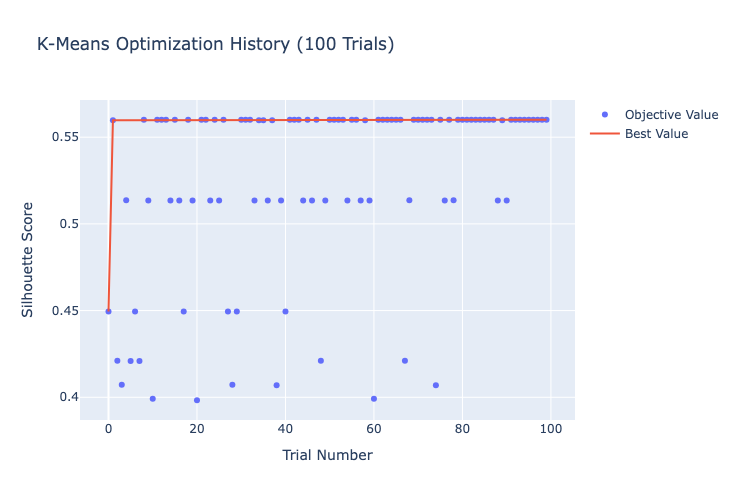

In [10]:
# Cell 8.1: Optuna Optimization History - K-Means
"""
Visualize how K-Means optimization improved over 100 trials.
Shows convergence to optimal hyperparameters.
"""
import optuna.visualization as vis

fig = vis.plot_optimization_history(study_kmeans)
fig.update_layout(
    title="K-Means Optimization History (100 Trials)",
    xaxis_title="Trial Number",
    yaxis_title="Silhouette Score",
    width=1000,
    height=500
)
fig.show()


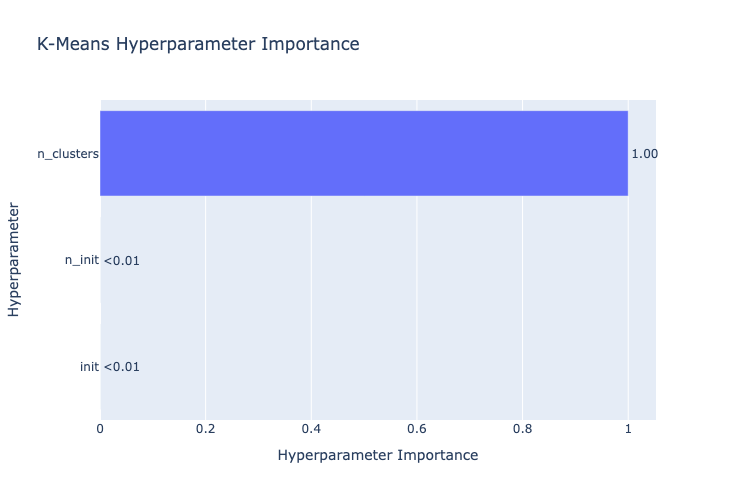

In [11]:
# Cell 8.2: Optuna Parameter Importance - K-Means
"""
Identify which hyperparameters had the greatest impact on silhouette score.
"""
fig = vis.plot_param_importances(study_kmeans)
fig.update_layout(
    title="K-Means Hyperparameter Importance",
    width=800,
    height=500
)
fig.show()


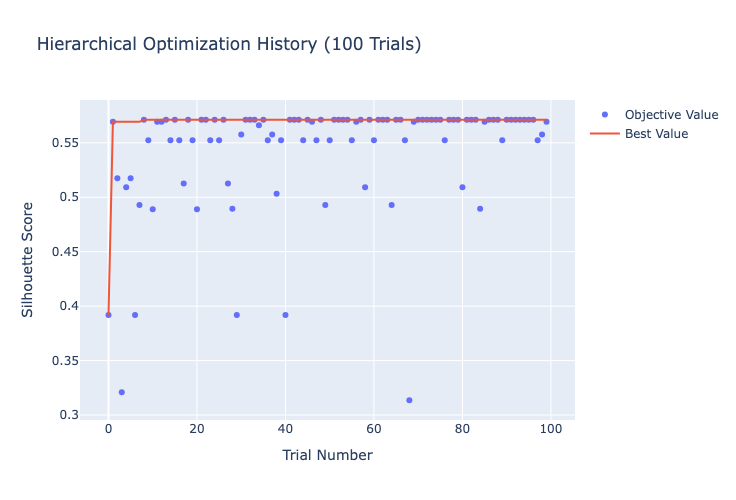

In [12]:
# Cell 8.3: Optuna Optimization History - Hierarchical
"""
Visualize how Hierarchical optimization improved over 100 trials.
"""
fig = vis.plot_optimization_history(study_hc)
fig.update_layout(
    title="Hierarchical Optimization History (100 Trials)",
    xaxis_title="Trial Number",
    yaxis_title="Silhouette Score",
    width=1000,
    height=500
)
fig.show()


In [13]:
# Cell 8.4: Optuna Parameter Importance - Hierarchical
"""
Identify which hyperparameters had the greatest impact on silhouette score.
"""
fig = vis.plot_param_importances(study_hc)
fig.update_layout(
    title="Hierarchical Hyperparameter Importance",
    width=800,
    height=500
)
fig.show()


In [14]:
# Cell 9: Train Final Models and Compare
"""
Train final models with best hyperparameters from Optuna.
Compare using multiple metrics to select winner.

Why these metrics:
- Silhouette: Measures separation ([-1,1], higher better)
- Davies-Bouldin: Measures compactness ([0,inf), lower better)
- Calinski-Harabasz: Variance ratio ([0,inf), higher better)
"""

print("Training final models with optimized parameters...\n")

# K-Means
kmeans_final = KMeans(**study_kmeans.best_params, random_state=42)
labels_kmeans = kmeans_final.fit_predict(X_clean)

# DBSCAN - check if any trials completed (not just started)
try:
    dbscan_final = DBSCAN(**study_dbscan.best_params)
    labels_dbscan = dbscan_final.fit_predict(X_clean)
    dbscan_valid = True
except ValueError:
    print("DBSCAN: All 50 trials pruned - unsuitable for this dataset")
    print("Reason: Unable to find valid eps/min_samples producing 2+ clusters with <50% noise\n")
    labels_dbscan = None
    dbscan_valid = False

# Hierarchical
hc_final = AgglomerativeClustering(**study_hc.best_params)
labels_hc = hc_final.fit_predict(X_clean)

# Evaluate
results = []
results.append(evaluate_clusters(X_clean, labels_kmeans, 'K-Means'))
if dbscan_valid:
    results.append(evaluate_clusters(X_clean, labels_dbscan, 'DBSCAN'))
results.append(evaluate_clusters(X_clean, labels_hc, 'Hierarchical'))

# Display comparison
df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

# Select winner
winner = compare_algorithms(results)
print(f"\nWINNER: {winner['algorithm']}")

Training final models with optimized parameters...

DBSCAN: All 50 trials pruned - unsuitable for this dataset
Reason: Unable to find valid eps/min_samples producing 2+ clusters with <50% noise

   algorithm  silhouette  davies_bouldin  calinski_harabasz  n_clusters
     K-Means    0.560065        0.676231         6625.69915           3
Hierarchical    0.571193        0.610175         5836.42920           3

ALGORITHM COMPARISON (Multi-Metric)
Algorithm       Silhouette   Davies-Bouldin  Composite 
K-Means         0.5601       0.6762          0.0000    
Hierarchical    0.5712       0.6102          1.0000     ← WINNER

WINNER: Hierarchical


In [15]:
# Cell 10: Apply Winner to Final Segmentation
"""
Use Hierarchical (winner) for final customer segmentation.
Add cluster labels to clean RFM data.
"""

# Use winner
labels_final = labels_hc
algorithm_final = 'Hierarchical'

# Add to RFM dataframe (USE rfm_clean, not rfm!)
rfm_clean['Cluster'] = labels_final

print(f"Final Model: {algorithm_final}")
print(f"Silhouette Score: {winner['silhouette']:.4f}")
print(f"Total Customers: {len(rfm_clean):,}")
print(f"Number of Clusters: {len(set(labels_final))}")
print(f"\nCluster Distribution:")
cluster_dist = rfm_clean['Cluster'].value_counts().sort_index()
for cluster_id, count in cluster_dist.items():
    pct = 100 * count / len(rfm_clean)
    print(f"  Cluster {cluster_id}: {count:4d} customers ({pct:5.1f}%)")

print(f"\nSegmented data ready for analysis and visualization.")


Final Model: Hierarchical
Silhouette Score: 0.5712
Total Customers: 4,273
Number of Clusters: 3

Cluster Distribution:
  Cluster 0:  257 customers (  6.0%)
  Cluster 1: 1221 customers ( 28.6%)
  Cluster 2: 2795 customers ( 65.4%)

Segmented data ready for analysis and visualization.


In [16]:
# Cell 11: Cluster Profiling
"""
Analyze RFM characteristics of each cluster to create business profiles.
"""
print("CLUSTER PROFILES - RFM ANALYSIS")

# Compute mean RFM values per cluster
cluster_profiles = rfm_clean.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].agg(['mean', 'median', 'std'])

print("\nMean RFM Values by Cluster:")
# Access MultiIndex columns correctly
for metric in ['Recency', 'Frequency', 'Monetary']:
    print(f"\n{metric}:")
    print(cluster_profiles[metric]['mean'].round(2))

print("BUSINESS INTERPRETATION")

# Analyze each cluster
for cluster_id in sorted(rfm_clean['Cluster'].unique()):
    cluster_data = rfm_clean[rfm_clean['Cluster'] == cluster_id]
    
    avg_recency = cluster_data['Recency'].mean()
    avg_frequency = cluster_data['Frequency'].mean()
    avg_monetary = cluster_data['Monetary'].mean()
    size = len(cluster_data)
    
    print(f"\nCluster {cluster_id}: {size} customers ({100*size/len(rfm_clean):.1f}%)")
    print(f"  Recency: {avg_recency:.1f} days (lower = more recent)")
    print(f"  Frequency: {avg_frequency:.1f} orders")
    print(f"  Monetary: ${avg_monetary:,.2f} total spend")
    
    # Business label
    if avg_recency < 50 and avg_frequency > 5 and avg_monetary > 2000:
        label = "VIP / Champions"
    elif avg_recency < 100 and avg_monetary > 1000:
        label = "Loyal Customers"
    elif avg_recency > 150 or avg_monetary < 500:
        label = "At-Risk / Lost"
    else:
        label = "Regular Customers"
    
    print(f"  → Business Segment: {label}")


CLUSTER PROFILES - RFM ANALYSIS

Mean RFM Values by Cluster:

Recency:
Cluster
0     12.98
1    234.04
2     40.04
Name: mean, dtype: float64

Frequency:
Cluster
0    15.60
1     1.69
2     3.41
Name: mean, dtype: float64

Monetary:
Cluster
0    5858.91
1     500.28
2    1199.83
Name: mean, dtype: float64
BUSINESS INTERPRETATION

Cluster 0: 257 customers (6.0%)
  Recency: 13.0 days (lower = more recent)
  Frequency: 15.6 orders
  Monetary: $5,858.91 total spend
  → Business Segment: VIP / Champions

Cluster 1: 1221 customers (28.6%)
  Recency: 234.0 days (lower = more recent)
  Frequency: 1.7 orders
  Monetary: $500.28 total spend
  → Business Segment: At-Risk / Lost

Cluster 2: 2795 customers (65.4%)
  Recency: 40.0 days (lower = more recent)
  Frequency: 3.4 orders
  Monetary: $1,199.83 total spend
  → Business Segment: Loyal Customers


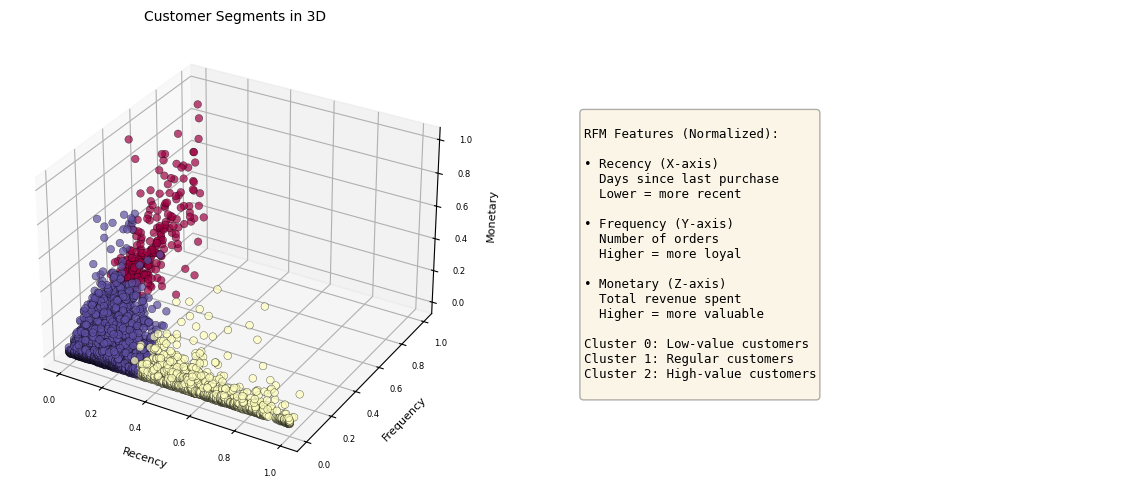

In [22]:
# Cell 12.a: 3D Cluster Visualization and RFM Feature Guide
X3d = X_clean
labels_final = labels_hc

scaler = MinMaxScaler()
X3d_norm = scaler.fit_transform(X3d)

unique_labels = sorted(set(labels_final))
colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))

fig = plt.figure(figsize=(12, 5))

# LEFT: 3D plot
ax1 = fig.add_subplot(121, projection='3d')
for lab, color in zip(unique_labels, colors):
    mask = labels_final == lab
    ax1.scatter(X3d_norm[mask, 0], X3d_norm[mask, 1], X3d_norm[mask, 2],
                c=[color], label=f"Cluster {lab}", s=30, alpha=0.7,
                edgecolors='k', linewidths=0.3)
ax1.set_xlabel("Recency", fontsize=8)
ax1.set_ylabel("Frequency", fontsize=8)
ax1.set_zlabel("Monetary", fontsize=8)
ax1.set_title("Customer Segments in 3D", fontsize=10)
ax1.tick_params(labelsize=6)

# RIGHT: Text explanation
ax2 = fig.add_subplot(122)
ax2.axis('off')

explanation = """
RFM Features (Normalized):

• Recency (X-axis)
  Days since last purchase
  Lower = more recent

• Frequency (Y-axis)
  Number of orders
  Higher = more loyal

• Monetary (Z-axis)
  Total revenue spent
  Higher = more valuable

Cluster 0: Low-value customers
Cluster 1: Regular customers
Cluster 2: High-value customers
"""

ax2.text(0.1, 0.5, explanation, fontsize=9, family='monospace',
         verticalalignment='center', bbox=dict(boxstyle='round', 
         facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.show()


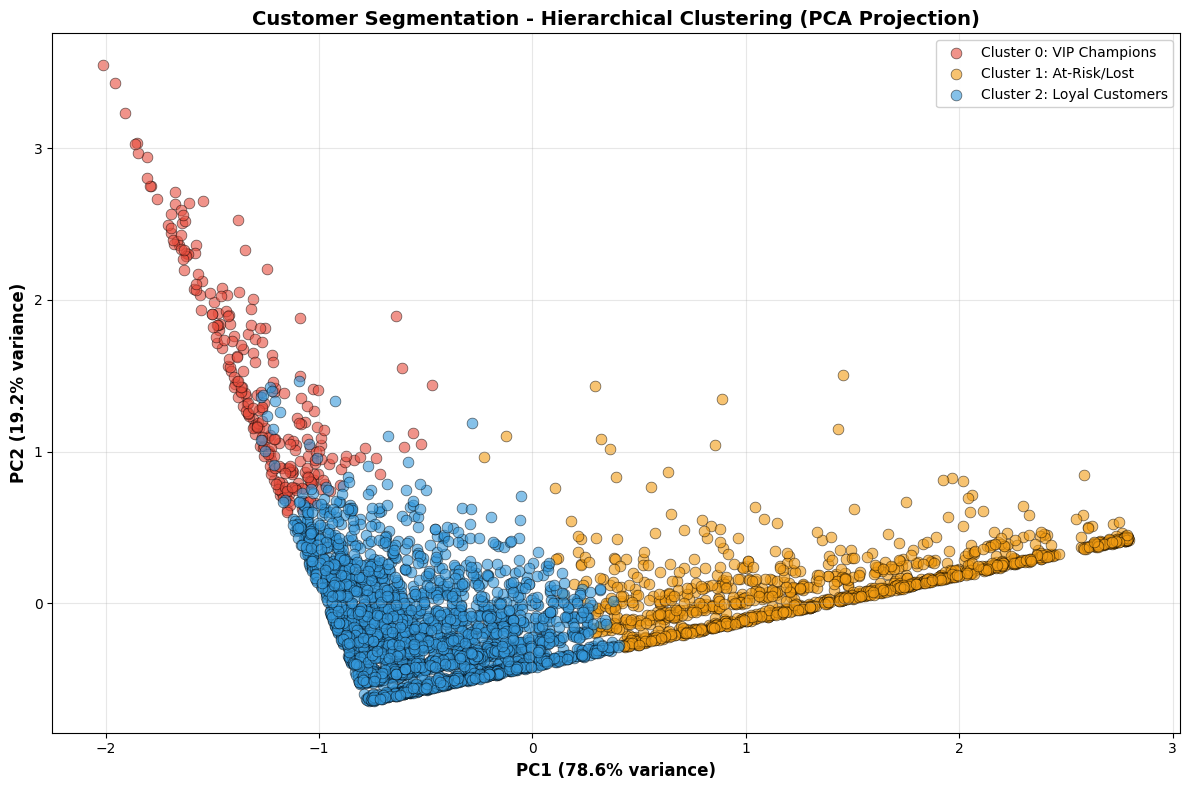


PCA Explained Variance: 97.8%


In [18]:
# Cell 12.b: Visualization - PCA Projection
"""
Visualize customer segments in 2D using PCA.
"""

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# PCA to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clean)

# Plot
fig, ax = plt.subplots(figsize=(12, 8))

# Define colors and labels
cluster_colors = {0: '#e74c3c', 1: '#f39c12', 2: '#3498db'}
cluster_labels = {0: 'VIP Champions', 1: 'At-Risk/Lost', 2: 'Loyal Customers'}

for cluster_id in sorted(rfm_clean['Cluster'].unique()):
    mask = labels_final == cluster_id
    ax.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        c=cluster_colors[cluster_id],
        label=f"Cluster {cluster_id}: {cluster_labels[cluster_id]}",
        s=60,
        alpha=0.6,
        edgecolors='k',
        linewidths=0.5
    )

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', 
              fontsize=12, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', 
              fontsize=12, fontweight='bold')
ax.set_title('Customer Segmentation - Hierarchical Clustering (PCA Projection)', 
             fontsize=14, fontweight='bold')
ax.legend(loc='best', framealpha=0.9, fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nPCA Explained Variance: {pca.explained_variance_ratio_.sum()*100:.1f}%")


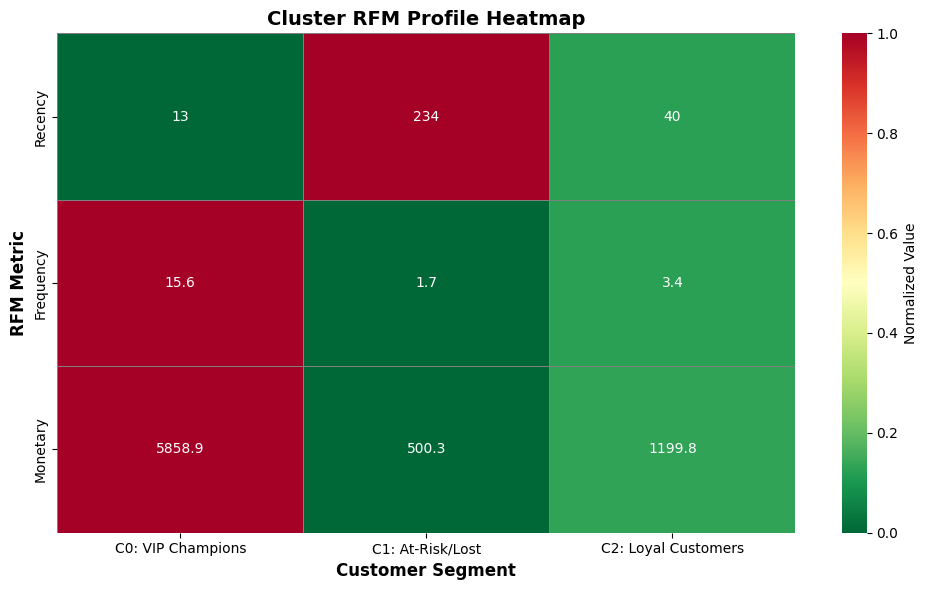


Interpretation:
• Green = High value | Red = Low value
• VIP: Low recency (recent), high frequency, high monetary
• At-Risk: High recency (dormant), low frequency, low monetary
• Loyal: Medium across all metrics


In [19]:
# Cell 13: Cluster Profile Heatmap
"""
Visualize RFM characteristics across clusters using heatmap.
"""

import seaborn as sns

# Compute normalized mean RFM per cluster
profiles = rfm_clean.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
profiles_norm = (profiles - profiles.min()) / (profiles.max() - profiles.min())

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    profiles_norm.T,
    annot=profiles.T.round(1),
    fmt='g',
    cmap='RdYlGn_r',  # Red=bad, Green=good
    cbar_kws={'label': 'Normalized Value'},
    ax=ax,
    linewidths=0.5,
    linecolor='gray',
    cbar=True
)

# Add cluster labels
cluster_labels = ['VIP Champions', 'At-Risk/Lost', 'Loyal Customers']
ax.set_xticklabels([f'C{i}: {cluster_labels[i]}' for i in range(3)], rotation=0)
ax.set_ylabel('RFM Metric', fontweight='bold', fontsize=12)
ax.set_xlabel('Customer Segment', fontweight='bold', fontsize=12)
ax.set_title('Cluster RFM Profile Heatmap', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("• Green = High value | Red = Low value")
print("• VIP: Low recency (recent), high frequency, high monetary")
print("• At-Risk: High recency (dormant), low frequency, low monetary")
print("• Loyal: Medium across all metrics")


In [20]:
# Cell 14: Export Results
"""
Saving final segmented data and summary.
"""

# Save segmented customers
rfm_clean.to_csv('customer_segments_final.csv', index=False)
print("Saved: customer_segments_final.csv")

# Save cluster summary
cluster_summary = rfm_clean.groupby('Cluster').agg({
    'CustomerID': 'count',
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(2)
cluster_summary.columns = ['Customer_Count', 'Avg_Recency', 'Avg_Frequency', 'Avg_Monetary']
cluster_summary['Segment_Label'] = ['VIP Champions', 'At-Risk/Lost', 'Loyal Customers']
cluster_summary.to_csv('cluster_summary.csv')
print("Saved: cluster_summary.csv")

print(" All results exported for business reporting")


Saved: customer_segments_final.csv
Saved: cluster_summary.csv
 All results exported for business reporting


In [21]:
df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))
winner = compare_algorithms(results)


   algorithm  silhouette  davies_bouldin  calinski_harabasz  n_clusters
     K-Means    0.560065        0.676231         6625.69915           3
Hierarchical    0.571193        0.610175         5836.42920           3

ALGORITHM COMPARISON (Multi-Metric)
Algorithm       Silhouette   Davies-Bouldin  Composite 
K-Means         0.5601       0.6762          0.0000    
Hierarchical    0.5712       0.6102          1.0000     ← WINNER
